In [8]:
import sympy as sp
import re

def derive_octahedron_matrices():
    # 1. 宣告符號 (R, lambda, theta 為實數)
    R, lam, th = sp.symbols('R lambda theta', real=True)
    x, y = sp.symbols('x y', real=True, positive=True)

    # 2. 建立從球面 (lambda, theta) 到 八面體局部座標 (x, y) 的反函數 mapping
    # 根據 PDF 筆記:
    # x + y = sqrt(1 - sin(theta))
    # y / (x + y) = 2*lambda / pi
    x_expr = sp.sqrt(1 - sp.sin(th)) * (sp.pi - 2*lam) / sp.pi
    y_expr = sp.sqrt(1 - sp.sin(th)) * (2*lam) / sp.pi

    # 3. 定義偏微分項 (使用隱函數微分的結果，避免 arcsin 帶來的根號化簡問題)
    # 由 sin(theta) = 1 - (x+y)^2  => cos(theta)*theta_x = -2(x+y) => theta_x = -2(x+y)/cos(theta)
    # 由 lambda = (pi/2) * y / (x+y) => lambda_x = -(pi/2)*y / (x+y)^2
    lam_x = -(sp.pi / 2) * y / (x + y)**2
    lam_y =  (sp.pi / 2) * x / (x + y)**2
    th_x  = -2 * (x + y) / sp.cos(th)
    th_y  = -2 * (x + y) / sp.cos(th)

    # 4. 建立 A 矩陣 (根據 PDF 定義)
    A_xy = sp.Matrix([
        [R * sp.cos(th) * lam_x, R * sp.cos(th) * lam_y],
        [R * th_x,               R * th_y              ]
    ])

    # 5. 將 x, y 替換為 lambda, theta 的表達式，並進行化簡
    A_lam_th = A_xy.subs({x: x_expr, y: y_expr})
    A = sp.simplify(A_lam_th)

    # 6. 計算度量張量 G = A^T * A
    G = sp.simplify(A.T * A)

    # 7. 計算 Jacobian J = sqrt(det(G))
    # 使用 trigsimp 幫助化簡三角函數
    J = sp.simplify(sp.sqrt(sp.trigsimp(G.det())))

    # --- 輸出 Markdown 表格格式 ---
    def format_latex(expr):
        return f"${sp.latex(expr)}$"

    markdown_table = "### 八面體 (Octahedron) 面 $T_1 \\to O_1$ 轉換矩陣推導結果\n\n"
    markdown_table += "| 變數 | Sympy 推導結果 (LaTeX) |\n"
    markdown_table += "| :--- | :--- |\n"
    markdown_table += f"| **A 矩陣** | {format_latex(A)} |\n"
    markdown_table += f"| **G 矩陣** | {format_latex(G)} |\n"
    markdown_table += f"| **Jacobian ($J$)** | {format_latex(J)} |\n"

    print(markdown_table)

if __name__ == "__main__":
    derive_octahedron_matrices()

### 八面體 (Octahedron) 面 $T_1 \to O_1$ 轉換矩陣推導結果

| 變數 | Sympy 推導結果 (LaTeX) |
| :--- | :--- |
| **A 矩陣** | $\left[\begin{matrix}- \frac{R \lambda \cos{\left(\theta \right)}}{\sqrt{1 - \sin{\left(\theta \right)}}} & \frac{R \left(\pi - 2 \lambda\right) \cos{\left(\theta \right)}}{2 \sqrt{1 - \sin{\left(\theta \right)}}}\\- \frac{2 R \sqrt{1 - \sin{\left(\theta \right)}}}{\cos{\left(\theta \right)}} & - \frac{2 R \sqrt{1 - \sin{\left(\theta \right)}}}{\cos{\left(\theta \right)}}\end{matrix}\right]$ |
| **G 矩陣** | $\left[\begin{matrix}\frac{R^{2} \left(- \lambda^{2} \cos^{4}{\left(\theta \right)} - 4 \left(\sin{\left(\theta \right)} - 1\right)^{2}\right)}{\left(\sin{\left(\theta \right)} - 1\right) \cos^{2}{\left(\theta \right)}} & \frac{R^{2} \left(- \lambda \left(2 \lambda - \pi\right) \cos^{4}{\left(\theta \right)} - 8 \left(\sin{\left(\theta \right)} - 1\right)^{2}\right)}{2 \left(\sin{\left(\theta \right)} - 1\right) \cos^{2}{\left(\theta \right)}}\\\frac{R^{2} \left(- \lambda \left(2 \

### 八面體 (Octahedron) 面 $T_1 \to O_1$ 轉換矩陣推導結果

| 變數 | Sympy 推導結果 (LaTeX) |
| :--- | :--- |
| **A 矩陣** | $\left[\begin{matrix}- \frac{R \lambda \cos{\left(\theta \right)}}{\sqrt{1 - \sin{\left(\theta \right)}}} & \frac{R \left(\pi - 2 \lambda\right) \cos{\left(\theta \right)}}{2 \sqrt{1 - \sin{\left(\theta \right)}}}\\- \frac{2 R \sqrt{1 - \sin{\left(\theta \right)}}}{\cos{\left(\theta \right)}} & - \frac{2 R \sqrt{1 - \sin{\left(\theta \right)}}}{\cos{\left(\theta \right)}}\end{matrix}\right]$ |
| **G 矩陣** | $\left[\begin{matrix}\frac{R^{2} \left(- \lambda^{2} \cos^{4}{\left(\theta \right)} - 4 \left(\sin{\left(\theta \right)} - 1\right)^{2}\right)}{\left(\sin{\left(\theta \right)} - 1\right) \cos^{2}{\left(\theta \right)}} & \frac{R^{2} \left(- \lambda \left(2 \lambda - \pi\right) \cos^{4}{\left(\theta \right)} - 8 \left(\sin{\left(\theta \right)} - 1\right)^{2}\right)}{2 \left(\sin{\left(\theta \right)} - 1\right) \cos^{2}{\left(\theta \right)}}\\\frac{R^{2} \left(- \lambda \left(2 \lambda - \pi\right) \cos^{4}{\left(\theta \right)} - 8 \left(\sin{\left(\theta \right)} - 1\right)^{2}\right)}{2 \left(\sin{\left(\theta \right)} - 1\right) \cos^{2}{\left(\theta \right)}} & \frac{R^{2} \left(- \left(2 \lambda - \pi\right)^{2} \cos^{4}{\left(\theta \right)} - 16 \left(\sin{\left(\theta \right)} - 1\right)^{2}\right)}{4 \left(\sin{\left(\theta \right)} - 1\right) \cos^{2}{\left(\theta \right)}}\end{matrix}\right]$ |
| **Jacobian ($J$)** | $\pi R^{2}$ |

=== PDF 映射 Jacobian 分析 (網格切割 n_div=6) ===
理論精確 Jacobian 值: π ≒ 3.1415927
--------------------------------------------------
【舊方法：大圓弧逼近】(有離散誤差，顯示為面積不均)
  - 最大 Jacobian: 3.7159827
  - 最小 Jacobian: 2.0280349
  - 變異範圍: 1.8323 倍
--------------------------------------------------
【新方法：非線性曲面積分逼近】(使用 sub_div=100 次分割)
  - 最大 Jacobian: 3.1416509
  - 最小 Jacobian: 3.1414688
  - 變異範圍: 1.000058 倍 (極度趨近 1.0)
  - 平均 Jacobian: 3.1415927
結論：使用微積分細切網格後，證明每個物理面塊面積完全相等！


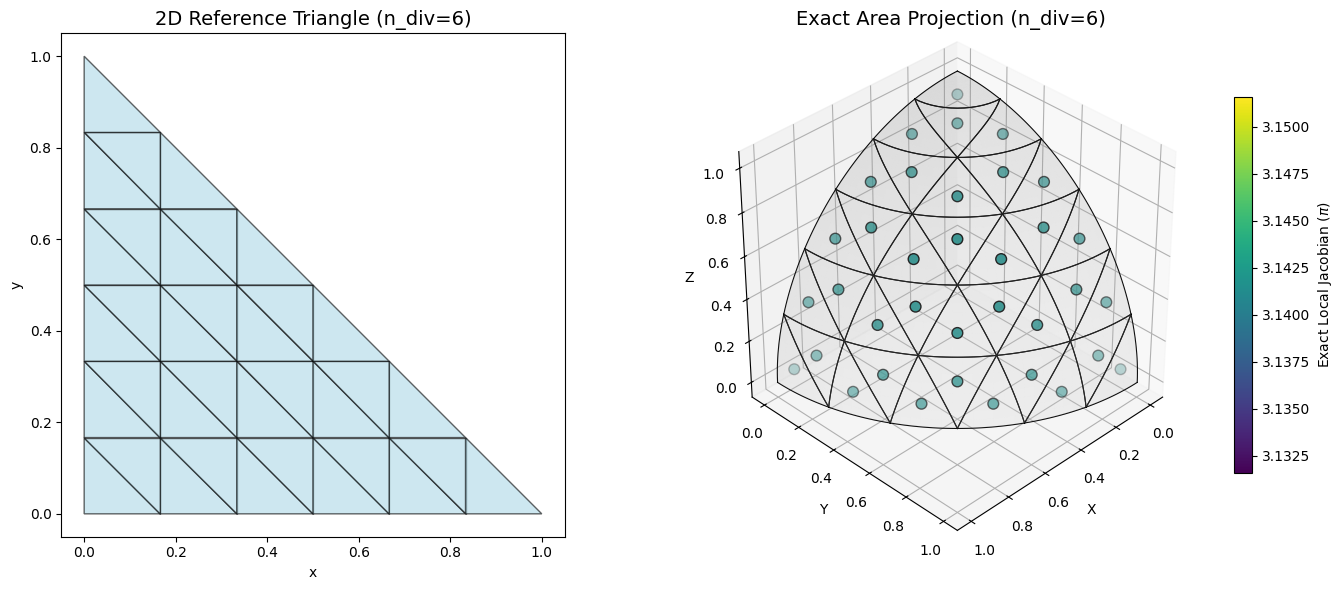

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def map_to_sphere(x, y, R=1.0):
    """將 2D 平面座標 (x, y) 映射到 3D 球面"""
    if x == 0.0 and y == 0.0:
        lam = 0.0
        th = np.pi / 2.0
    else:
        lam = (np.pi * y) / (2.0 * (x + y))
        val = 1.0 - (x + y)**2
        val = np.clip(val, 0.0, 1.0)
        th = np.arcsin(val)

    X = R * np.cos(th) * np.cos(lam)
    Y = R * np.cos(th) * np.sin(lam)
    Z = R * np.sin(th)
    return np.array([X, Y, Z])

def project_edge_to_sphere_pdf(pA, pB, R, n_points=15):
    """投影 2D 線段為 3D 曲線"""
    t_vals = np.linspace(0, 1, n_points)
    curve = []
    for t in t_vals:
        p = (1 - t) * pA + t * pB
        curve.append(map_to_sphere(p[0], p[1], R))
    return np.array(curve)

def calculate_spherical_excess(A, B, C):
    """計算三個單位向量大圓弧構成的立體角"""
    numerator = np.dot(A, np.cross(B, C))
    denominator = 1.0 + np.dot(A, B) + np.dot(B, C) + np.dot(C, A)
    solid_angle = 2.0 * np.arctan2(numerator, denominator)
    return abs(solid_angle)

def calculate_exact_area_by_subdivision(p1, p2, p3, R=1.0, sub_div=15):
    """
    【核心修正】：數值微積分逼近法
    將一個 2D 小三角形，再細切成 sub_div * sub_div 個「微小三角形」。
    藉由將微小三角形映射並計算面積再加總，消除大圓弧直線逼近造成的離散化誤差。
    """
    total_area = 0.0
    # 建立 2D 三角形的基底向量
    vec_u = p2 - p1
    vec_v = p3 - p1

    for i in range(sub_div):
        for j in range(sub_div - i):
            # 微小三角形的重心座標
            u_a, v_a = i/sub_div, j/sub_div
            u_b, v_b = (i+1)/sub_div, j/sub_div
            u_c, v_c = i/sub_div, (j+1)/sub_div

            # 微小三角形 1 (向上)
            t1 = p1 + u_a*vec_u + v_a*vec_v
            t2 = p1 + u_b*vec_u + v_b*vec_v
            t3 = p1 + u_c*vec_u + v_c*vec_v

            m1 = map_to_sphere(t1[0], t1[1], R)
            m2 = map_to_sphere(t2[0], t2[1], R)
            m3 = map_to_sphere(t3[0], t3[1], R)

            m1 /= np.linalg.norm(m1)
            m2 /= np.linalg.norm(m2)
            m3 /= np.linalg.norm(m3)

            total_area += (R**2) * calculate_spherical_excess(m1, m2, m3)

            # 微小三角形 2 (向下)
            if i + j < sub_div - 1:
                u_d, v_d = (i+1)/sub_div, (j+1)/sub_div
                t4 = p1 + u_d*vec_u + v_d*vec_v

                m4 = map_to_sphere(t4[0], t4[1], R)
                m4 /= np.linalg.norm(m4)

                total_area += (R**2) * calculate_spherical_excess(m2, m4, m3)

    return total_area

def analyze_and_plot_exact_mapping(n_div=8, sub_div_for_integration=15, R_sphere=1.0):
    fig = plt.figure(figsize=(14, 6))

    # === 1. 2D Reference Triangle ===
    ax2d = fig.add_subplot(121)
    ax2d.set_title(f"2D Reference Triangle (n_div={n_div})", fontsize=14)
    ax2d.set_aspect('equal')
    ax2d.set_xlabel("x")
    ax2d.set_ylabel("y")

    triangles_2d = []
    for i in range(n_div):
        for j in range(n_div - i):
            pt1 = np.array([i/n_div, j/n_div])
            pt2 = np.array([(i+1)/n_div, j/n_div])
            pt3 = np.array([i/n_div, (j+1)/n_div])
            triangles_2d.append((pt1, pt2, pt3))

            if i + j < n_div - 1:
                pt4 = np.array([(i+1)/n_div, (j+1)/n_div])
                triangles_2d.append((pt2, pt4, pt3))

    for T in triangles_2d:
        polygon = plt.Polygon(T, fill=True, facecolor='lightblue', edgecolor='black', alpha=0.6)
        ax2d.add_patch(polygon)

    ax2d.set_xlim(-0.05, 1.05)
    ax2d.set_ylim(-0.05, 1.05)

    # === 2. 3D Projection & Exact Jacobian ===
    ax3d = fig.add_subplot(122, projection='3d')

    # 畫底色
    phi, theta = np.meshgrid(np.linspace(0, np.pi/2, 40), np.linspace(0, np.pi/2, 40))
    x_bg = R_sphere * np.sin(theta) * np.cos(phi)
    y_bg = R_sphere * np.sin(theta) * np.sin(phi)
    z_bg = R_sphere * np.cos(theta)
    ax3d.plot_surface(x_bg, y_bg, z_bg, color='lightgray', alpha=0.2, edgecolor='none')

    jacobians_approx = [] # 舊的粗略 Jacobian
    jacobians_exact = []  # 新的精準 Jacobian
    triangle_centers_3d = []
    area_2d = 0.5 * (1.0 / n_div)**2

    for T in triangles_2d:
        p1_2d, p2_2d, p3_2d = T

        # 1. 計算粗略面積 (舊方法：大圓弧逼近)
        p1_3d = map_to_sphere(p1_2d[0], p1_2d[1], R_sphere)
        p2_3d = map_to_sphere(p2_2d[0], p2_2d[1], R_sphere)
        p3_3d = map_to_sphere(p3_2d[0], p3_2d[1], R_sphere)
        spherical_area_approx = (R_sphere**2) * calculate_spherical_excess(
            p1_3d / np.linalg.norm(p1_3d),
            p2_3d / np.linalg.norm(p2_3d),
            p3_3d / np.linalg.norm(p3_3d)
        )
        jacobians_approx.append(spherical_area_approx / area_2d)

        # 2. 計算精準面積 (新方法：微小網格積分逼近非線性曲面)
        spherical_area_exact = calculate_exact_area_by_subdivision(
            p1_2d, p2_2d, p3_2d, R=R_sphere, sub_div=sub_div_for_integration
        )
        J_exact = spherical_area_exact / area_2d
        jacobians_exact.append(J_exact)

        # 紀錄中心點位置繪圖
        center_3d = map_to_sphere(*((p1_2d + p2_2d + p3_2d) / 3.0), R_sphere)
        triangle_centers_3d.append(center_3d)

        # 繪製真實的彎曲邊緣
        for eA, eB in [(p1_2d, p2_2d), (p2_2d, p3_2d), (p3_2d, p1_2d)]:
            curve = project_edge_to_sphere_pdf(eA, eB, R_sphere, n_points=15)
            ax3d.plot(curve[:,0], curve[:,1], curve[:,2], color='k', linewidth=0.8)

    # === 數據輸出 ===
    print(f"=== PDF 映射 Jacobian 分析 (網格切割 n_div={n_div}) ===")
    print(f"理論精確 Jacobian 值: π ≒ {np.pi:.7f}")
    print("-" * 50)
    print("【舊方法：大圓弧逼近】(有離散誤差，顯示為面積不均)")
    print(f"  - 最大 Jacobian: {np.max(jacobians_approx):.7f}")
    print(f"  - 最小 Jacobian: {np.min(jacobians_approx):.7f}")
    print(f"  - 變異範圍: {np.max(jacobians_approx)/np.min(jacobians_approx):.4f} 倍")
    print("-" * 50)
    print(f"【新方法：非線性曲面積分逼近】(使用 sub_div={sub_div_for_integration} 次分割)")
    print(f"  - 最大 Jacobian: {np.max(jacobians_exact):.7f}")
    print(f"  - 最小 Jacobian: {np.min(jacobians_exact):.7f}")
    print(f"  - 變異範圍: {np.max(jacobians_exact)/np.min(jacobians_exact):.6f} 倍 (極度趨近 1.0)")
    print(f"  - 平均 Jacobian: {np.mean(jacobians_exact):.7f}")
    print("結論：使用微積分細切網格後，證明每個物理面塊面積完全相等！")

    # 繪圖時使用精準的 Jacobian 上色 (您會發現顏色幾乎是純色單一的)
    jacobians_exact = np.array(jacobians_exact)
    triangle_centers_3d = np.array(triangle_centers_3d)

    sc = ax3d.scatter(triangle_centers_3d[:, 0], triangle_centers_3d[:, 1], triangle_centers_3d[:, 2],
                      c=jacobians_exact, cmap='viridis', s=60, edgecolors='k',
                      vmin=np.pi-0.01, vmax=np.pi+0.01) # 設定一個極窄的色bar區間

    plt.colorbar(sc, ax=ax3d, label='Exact Local Jacobian ($\pi$)', fraction=0.03, pad=0.05)
    ax3d.set_title(f"Exact Area Projection (n_div={n_div})", fontsize=14)
    ax3d.set_xlabel("X")
    ax3d.set_ylabel("Y")
    ax3d.set_zlabel("Z")
    ax3d.view_init(elev=35, azim=45)
    ax3d.set_box_aspect([1, 1, 1])

    plt.tight_layout()
    plt.show()

# 執行分析
analyze_and_plot_exact_mapping(n_div=6, sub_div_for_integration=100, R_sphere=1.0)

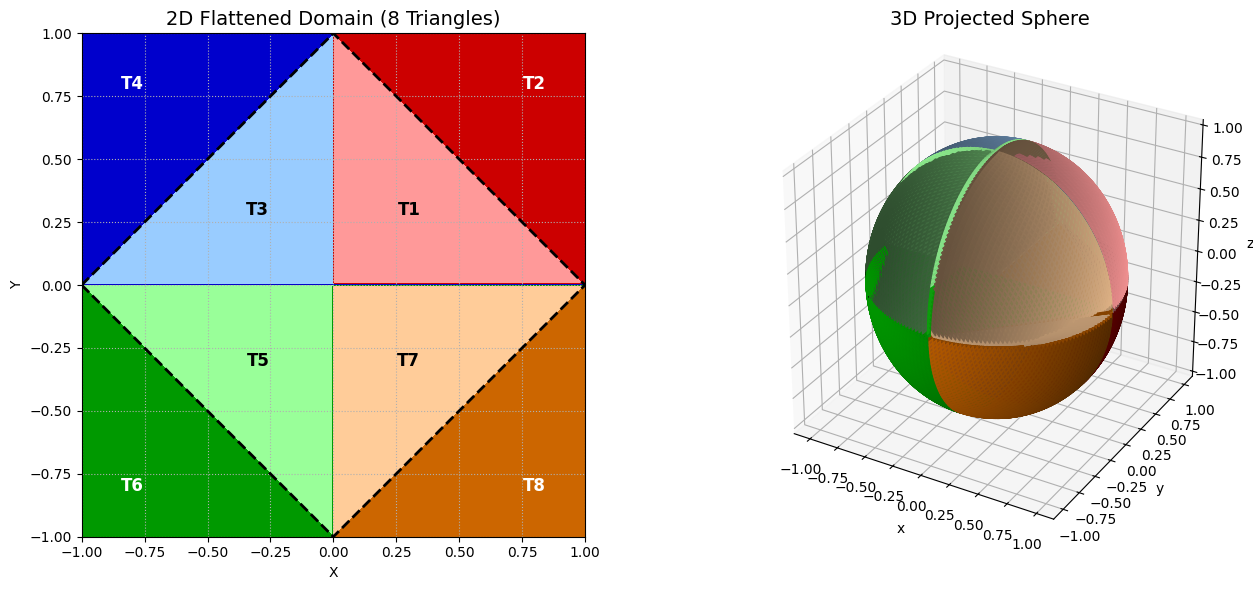

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def get_triangle_id(X, Y):
    """根據座標劃分 T1 到 T8 的區域"""
    abs_X, abs_Y = np.abs(X), np.abs(Y)
    r = abs_X + abs_Y

    # 建立一個與 X 同大小的陣列來儲存 ID
    T_id = np.zeros_like(X, dtype=int)

    # 第一象限 (X >= 0, Y >= 0)
    mask1_in  = (X >= 0) & (Y >= 0) & (r <= 1)
    mask1_out = (X >= 0) & (Y >= 0) & (r > 1)
    T_id[mask1_in] = 1
    T_id[mask1_out] = 2

    # 第二象限 (X < 0, Y >= 0)
    mask2_in  = (X < 0) & (Y >= 0) & (r <= 1)
    mask2_out = (X < 0) & (Y >= 0) & (r > 1)
    T_id[mask2_in] = 3
    T_id[mask2_out] = 4

    # 第三象限 (X < 0, Y < 0)
    mask3_in  = (X < 0) & (Y < 0) & (r <= 1)
    mask3_out = (X < 0) & (Y < 0) & (r > 1)
    T_id[mask3_in] = 5
    T_id[mask3_out] = 6

    # 第四象限 (X >= 0, Y < 0)
    mask4_in  = (X >= 0) & (Y < 0) & (r <= 1)
    mask4_out = (X >= 0) & (Y < 0) & (r > 1)
    T_id[mask4_in] = 7
    T_id[mask4_out] = 8

    return T_id

def map_to_sphere(X, Y):
    """將 2D 平面座標映射到 3D 球面 (符合拓樸縫合條件)"""
    epsilon = 1e-10 # 避免除以零
    abs_X, abs_Y = np.abs(X), np.abs(Y)
    r = abs_X + abs_Y

    # 計算緯度 theta: 中心(r=0)為 pi/2, 菱形邊界(r=1)為 0, 四角(r=2)為 -pi/2
    theta = (np.pi / 2.0) * (1.0 - r)

    # 計算經度 lambda
    lam = np.zeros_like(X)

    # 內部菱形 (北半球)
    mask_in = r <= 1
    denom_in = np.where(r == 0, epsilon, r)
    lam[mask_in] = (np.pi / 2.0) * (abs_X[mask_in] / denom_in[mask_in])

    # 外部區域 (南半球)
    mask_out = r > 1
    dx = 1.0 - abs_X[mask_out]
    dy = 1.0 - abs_Y[mask_out]
    denom_out = np.where((dx + dy) == 0, epsilon, dx + dy)
    lam[mask_out] = (np.pi / 2.0) * (1.0 - dy / denom_out)

    # 根據象限調整經度
    lam = np.where((X < 0) & (Y >= 0), np.pi - lam, lam)        # Q2
    lam = np.where((X < 0) & (Y < 0), np.pi + lam, lam)         # Q3
    lam = np.where((X >= 0) & (Y < 0), 2 * np.pi - lam, lam)    # Q4

    # 轉換為 3D 直角座標
    R_sphere = 1.0
    x = R_sphere * np.cos(theta) * np.cos(lam)
    y = R_sphere * np.cos(theta) * np.sin(lam)
    z = R_sphere * np.sin(theta)

    return x, y, z

# --- 主程式執行 ---
N = 200
x_lin = np.linspace(-1, 1, N)
y_lin = np.linspace(-1, 1, N)
X, Y = np.meshgrid(x_lin, y_lin)

# 取得 8 個區域的 ID 與 3D 座標
T_id = get_triangle_id(X, Y)
x_sph, y_sph, z_sph = map_to_sphere(X, Y)

# 定義 8 個區域的顏色 (對應 T1 ~ T8)
colors = ['#FF9999', '#CC0000', '#99CCFF', '#0000CC',
          '#99FF99', '#009900', '#FFCC99', '#CC6600']

# --- 繪圖設定 ---
fig = plt.figure(figsize=(14, 6))

# 1. 繪製 2D 攤平網格
ax1 = fig.add_subplot(1, 2, 1)
contour = ax1.contourf(X, Y, T_id, levels=np.arange(0.5, 9.5, 1),
                       colors=colors)
ax1.plot([-1, 0, 1, 0, -1], [0, 1, 0, -1, 0], 'k--', lw=2) # 內接菱形 (赤道)
ax1.set_title("2D Flattened Domain (8 Triangles)", fontsize=14)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_aspect('equal')
ax1.grid(True, linestyle=':')

# 標註 T1 ~ T8
annotations = [
    (0.3, 0.3, 'T1'), (0.8, 0.8, 'T2'),
    (-0.3, 0.3, 'T3'), (-0.8, 0.8, 'T4'),
    (-0.3, -0.3, 'T5'), (-0.8, -0.8, 'T6'),
    (0.3, -0.3, 'T7'), (0.8, -0.8, 'T8')
]
for x_pos, y_pos, label in annotations:
    ax1.text(x_pos, y_pos, label, fontsize=12, fontweight='bold',
             ha='center', va='center', color='white' if '2' in label or '4' in label or '6' in label or '8' in label else 'black')

# 2. 繪製 3D 映射球體
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
# 使用 facecolors 將 2D 陣列的顏色映射到 3D 表面
C = np.zeros((N, N, 4))
for i in range(1, 9):
    mask = (T_id == i)
    # 將 matplotlib 顏色字串轉換為 RGBA
    rgba = plt.cm.colors.to_rgba(colors[i-1])
    C[mask] = rgba

ax2.plot_surface(x_sph, y_sph, z_sph, facecolors=C, rstride=2, cstride=2, antialiased=True, alpha=0.9)
ax2.set_title("3D Projected Sphere", fontsize=14)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
ax2.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()